# Theorem 2: Non - Homogeneous Integrals  

Testing integrals for non-homogeneous functions for which Euler's theorem cannot be applied. 

In [112]:
#using Revise

## Import Packages

In [5]:
using StaticArrays 
using LinearAlgebra # provides the function norm 
using HCubature # provides adaptive numerical integration 

using Test # provides testing functionality 
using Plots

function hcubature_count(f, a, b; kws...)
    count = 0
    i = hcubature(a, b; kws...) do x
        count += 1
        # display(count)
        f(x)
    end
    return (i..., count)
end

const Point3D = SVector{3,Float64};

include("edge_struct_definitions.jl");

#include("point-edge-interactions.jl"); # how to get rid of the semi-colom here?  

## Section 1: Introduction

More later. 

## Section 2: Test Cases

In [117]:
h = .5
R0 = 0.1
s1 = .1; s2 = 1. 
I8val      = I8(s2,h,R0) - I8(s1,h,R0)
I8valnum   = hcubature(s -> I8integrand(s[1],h,R0) , (s1,), (s2,))[1]
I9val      = I9(s2,h,R0) - I9(s1,h,R0)
I9valnum   = hcubature(s -> I9integrand(s[1],h,R0) , (s1,), (s2,))[1]
I10val     = I10(s2,h,R0) - I10(s1,h,R0)
I10valnum  = hcubature(s -> I10integrand(s[1],h,R0) , (s1,), (s2,))[1]
I11val     = I11(s2,h,R0) - I11(s1,h,R0)
I11valnum  = hcubature(s -> I11integrand(s[1],h,R0) , (s1,), (s2,))[1]
I12val     = I12(s2,h,R0) - I12(s1,h,R0)
I12valnum  = hcubature(s -> I12integrand(s[1],h,R0) , (s1,), (s2,))[1]
I13val     = I13(s2,h,R0) - I13(s1,h,R0)
I13valnum  = hcubature(s -> I13integrand(s[1],h,R0) , (s1,), (s2,))[1]
I14hatval     = I14hat(s2,h,R0) - I14hat(s1,h,R0)
I14hatvalnum  = hcubature(s -> I14hatintegrand(s[1],h,R0) , (s1,), (s2,))[1]
I15hatval     = I15hat(s2,h,R0) - I15hat(s1,h,R0)
I15hatvalnum  = hcubature(s -> I15hatintegrand(s[1],h,R0) , (s1,), (s2,))[1]
I16hatval     = I16hat(s2,h,R0) - I16hat(s1,h,R0)
I16hatvalnum  = hcubature(s -> I16hatintegrand(s[1],h,R0) , (s1,), (s2,))[1]
I17hatval     = I17hat(s2,h,R0) - I17hat(s1,h,R0)
I17hatvalnum  = hcubature(s -> I17hatintegrand(s[1],h,R0) , (s1,), (s2,))[1]

@test I8val ≈ I8valnum 
@test I9val ≈ I9valnum 
@test I10val ≈ I10valnum 
@test I11val ≈ I11valnum
@test I12val ≈ I12valnum 
@test I13val ≈ I13valnum
@test I14hatval ≈ I14hatvalnum
@test I15hatval ≈ I15hatvalnum
@test I16hatval ≈ I16hatvalnum
@test I17hatval ≈ I17hatvalnum

Test Passed

### More severe testing - Currently fails 

In [279]:
h  = 1. 
R0 = 1e-6 
s1 = 0.; s2 = 1. 
I13val     = I13(s2,h,R0) - I13(s1,h,R0)
I13valnum  = hcubature(s -> I13integrand(s[1],h,R0) , (s1,), (s2,))[1]
println(" ana. I13 = ", I13val)
println(" num. I13 = ", I13valnum)

 ana. I13 = 0.10943125795765718
 num. I13 = 0.10947570823033538


## Section 3: Plotting $f_1$, $f_2$ and $f_3$ for $h=1$ and $R0 = 0$

The goal is to show that these plots look bening and that therefore numerical integration is feasible. 

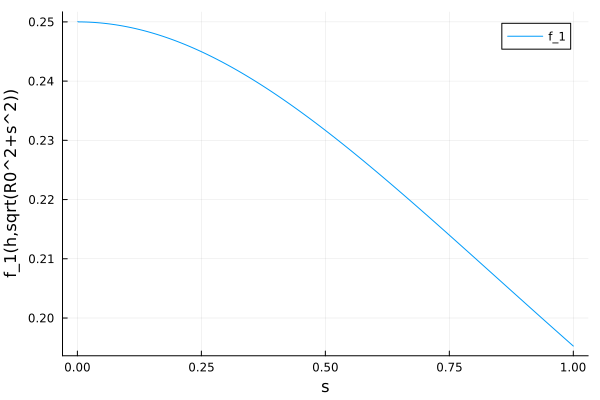

In [263]:
h  = 1.  
R0 = 0.
s1 = 0.; s2 = 1.; svec = LinRange(s1,s2,1000) 
f1vec = [f3(h,si) for si in svec]
plot(svec, f1vec,label="f_1")
xlabel!("s"); ylabel!("f_1(h,sqrt(R0^2+s^2))")

## Section 5: Plotting the Integrand  

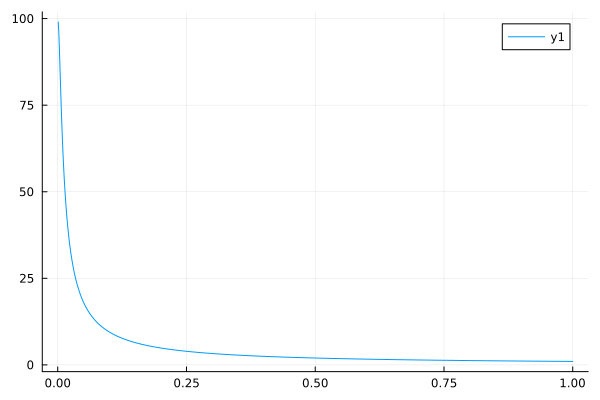

In [250]:
h = .005
R0 = 0.
s1 = 0.; s2 = 1.; svec = LinRange(s1,s2,1000) 
I8integrandvec = [I8integrand(si,h,R0) for si in svec]
plot(svec, I8integrandvec)

In [280]:
function myI8delta(s1,s2,h,R0)   
    val = hcubature(s -> f1(h,sqrt(s[1]^2+R0^2)), (s1,), (s2,))[1]
    return val 
end 

function myI9delta(s1,s2,h,R0)   
    val = hcubature(s -> (s/h)*f1(h,sqrt(s[1]^2+R0^2)), (s1,), (s2,))[1]
    return val 
end 

function myI10delta(s1,s2,h,R0)   
    val = hcubature(s -> f2(h,sqrt(s[1]^2+R0^2)), (s1,), (s2,))[1]
    return val 
end 

function myI11delta(s1,s2,h,R0)   
    val = hcubature(s -> (s/h)*f2(h,sqrt(s[1]^2+R0^2)), (s1,), (s2,))[1]
    return val 
end 

function myI12delta(s1,s2,h,R0)   
    val = hcubature(s -> f3(h,sqrt(s[1]^2+R0^2)), (s1,), (s2,))[1]
    return val 
end 

function myI13delta(s1,s2,h,R0)   
    val = hcubature(s -> (s/h)*f3(h,sqrt(s[1]^2+R0^2)), (s1,), (s2,))[1]
    return val 
end 

myI13delta (generic function with 1 method)

In [270]:
myI13delta(0.,1.,1.,0.)

1-element SVector{1, Float64} with indices SOneTo(1):
 0.10947570823176438

In [274]:
I13(1.,1.,0)

0.6094757082487301

## Section 4: (Speculative) Testing the case $R_0 \rightarrow 0$ - How to perform regularization such that information is not cut off? 

Analytical and numerical values for $I_8$ derivate in case that $R_0 \rightarrow 0$. We expect this to be due poor handling of the singularity in the numerical integration. 

$I_{14}$ becomes large for $R=0$. There $I_8$ becomes large as well (independent of any regularization between applied). 

Why does $I_{14}$ becomes large for $R=0$? 

In [242]:
function I8free(s,h,R0)
    t0 = sqrt(h^2+R0^2)
    return I14(s,h,R0) + asinh(s/t0) - h/R0*atan(s/R0)
end

function I8regular(s,h,R0)
    cutoff = 1e-12
    t0 = sqrt(h^2+R0^2)
    return I14(s,h,R0) + asinh(s/t0) - h/(R0+cutoff)*atan(s/R0)
end

function I8integrand(s,h,R0)
    # cutoff = 1e-12; if (R0<cutoff) R0 = cutoff end
    arg = sqrt(R0^2+s^2)
    return f1(h,arg) 
end

I8integrand (generic function with 1 method)

In [243]:
# what makes I8regular so large? 
[I8regular(.1,.5,0.), I8regular(1.,.5,0)]

2-element Vector{Float64}:
 0.19873046875
 1.443603515625

In [244]:
function I14(s,h,R0)
    t0 = sqrt(h^2+R0^2)
    argplus = sqrt(t0^2+s^2)+h
    argmin  = sqrt(t0^2+s^2)-h
    return sign(s)*(I17plus(argmin,h,R0) - I17min(argplus,h,R0)) 
end

[I14(.1,.5,0), I14(1.,.5,0)]

2-element Vector{Float64}:
 7.853981633974482e11
 7.853981633974482e11

In [245]:
function I17plus(x,h,R0)
    cutoff = 1e-12; 
    t0 = sqrt(h^2+R0^2)
    arg = -R0^2/(x*t0)+h/t0
    return h/(2*(R0+cutoff))*asin(arg) 
end 

[I17plus(.1,.5,0), I17plus(1.,.5,0)]

2-element Vector{Float64}:
 3.926990816987241e11
 3.926990816987241e11

In [246]:
function I17min(x,h,R0)
    cutoff = 1e-12
    t0 = sqrt(h^2+R0^2)
    arg  = -R0^2/(x*t0)-h/t0
    return h/(2*(R0+cutoff))*asin(arg)  
end

[I17min(.1,.5,0), I17min(1.,.5,0)]

2-element Vector{Float64}:
 -3.926990816987241e11
 -3.926990816987241e11

In [207]:
h = .5
R0 = 0
s1 = .9; s2 = 1. 
I8valnum   = hcubature(s -> I8integrand(s[1],h,R0) , (s1,), (s2,))[1]
I8valana   = I8(s2,h,R0) - I8(s1,h,R0)
println(" num. I8     = ", I8valnum)
println(" I8(s2,h,R0) = ", I8(s2,h,R0))
println(" I8(s1,h,R0) = ", I8(s1,h,R0))
println(" ana. I8     = ", I8valana)

 num. I8     = 0.06356409515249868
 I8(s2,h,R0) = 1.9434814453125
 I8(s1,h,R0) = 1.906005859375
 ana. I8     = 0.0374755859375
